### Celda 1: Preparación del entorno en Kaggle

In [1]:
!pip install -U ultralytics
# Checks rapidos del stack
!yolo checks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 93.4 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 w

### Celda 2: Importación de librerías y configuración básica


In [2]:
import os, sys, platform
from pathlib import Path

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Working dir:", os.getcwd())
print("Kaggle input dir exists:", Path("/kaggle/input").exists())


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
Working dir: /kaggle/working
Kaggle input dir exists: True


### Celda 3: Definir ruta y seteo del dataset Kaggle


In [3]:
import os, glob
from pathlib import Path
# Aqui va la ruta del Data Set (Input)
DATASET_ROOT = Path("/kaggle/input/datasets/sujan97/screws-and-nuts-image")
#DATASET_ROOT = Path("/kaggle/input/screws-and-nuts-image")


# Listar datasets montados
print("Datasets en /kaggle/input:")
for p in sorted(DATASET_ROOT.iterdir()):
    if p.is_dir():
        print(" -", p.name)

from pathlib import Path
import json

# Ajustar este nombre segun lo que muestre la anterior celda en DATASET_ROOT
DS_NAME = "datasets/sujan97/screws-and-nuts-image"  # ejemplo, ajustar si Kaggle lo monta con otro nombre


DS_ROOT = Path("/kaggle/input") / DS_NAME
print("DS_ROOT:", DS_ROOT)

IMAGES_DIR = DS_ROOT / "images"
TRAIN_JSON = DS_ROOT / "mvtec_screws_train.json"
VAL_JSON   = DS_ROOT / "mvtec_screws_val.json"
TEST_JSON  = DS_ROOT / "mvtec_screws_test.json"

print("IMAGES_DIR exists:", IMAGES_DIR.exists())
print("TRAIN_JSON exists:", TRAIN_JSON.exists())
print("VAL_JSON exists:", VAL_JSON.exists())
print("TEST_JSON exists:", TEST_JSON.exists())

Datasets en /kaggle/input:
 - images
DS_ROOT: /kaggle/input/datasets/sujan97/screws-and-nuts-image
IMAGES_DIR exists: True
TRAIN_JSON exists: True
VAL_JSON exists: True
TEST_JSON exists: True


### Celda 4: Crear estructura YOLO en /kaggle/working

In [4]:
import shutil
from pathlib import Path

OUT_ROOT = Path("/kaggle/working/mvtec_yolo")
IMG_OUT  = OUT_ROOT / "images"
LBL_OUT  = OUT_ROOT / "labels"

for split in ["train", "val", "test"]:
    (IMG_OUT / split).mkdir(parents=True, exist_ok=True)
    (LBL_OUT / split).mkdir(parents=True, exist_ok=True)

print("Estructura creada en:", OUT_ROOT)


Estructura creada en: /kaggle/working/mvtec_yolo


### Celda 5: Funciones: OBB (row,col,w,h,phi) -> AABB (xmin,ymin,xmax,ymax)


In [5]:
import math
import numpy as np

def obb_to_aabb(row, col, w, h, phi):
    """
    Convierte una caja rotada Bounding Boxes Orientados (OBB) definida por:
      - centro (row, col)
      - width w y height h (en pixeles)
      - angulo phi (radianes)
    a una caja axis-aligned AABB: xmin, ymin, xmax, ymax.

    Notas:
    - row = eje y
    - col = eje x
    """
    cx = float(col)
    cy = float(row)
    w = float(w)
    h = float(h)
    phi = float(phi)

    # Vectores semi-ejes rotados
    cos_p = math.cos(phi)
    sin_p = math.sin(phi)

    # Semi-ejes (mitad)
    dx1 = (w/2.0) * cos_p
    dy1 = (w/2.0) * sin_p
    dx2 = -(h/2.0) * sin_p
    dy2 = (h/2.0) * cos_p

    # 4 corners del rectangulo rotado
    corners = np.array([
        [cx + dx1 + dx2, cy + dy1 + dy2],
        [cx + dx1 - dx2, cy + dy1 - dy2],
        [cx - dx1 - dx2, cy - dy1 - dy2],
        [cx - dx1 + dx2, cy - dy1 + dy2],
    ], dtype=np.float32)

    xmin = float(corners[:,0].min())
    xmax = float(corners[:,0].max())
    ymin = float(corners[:,1].min())
    ymax = float(corners[:,1].max())
    return xmin, ymin, xmax, ymax

### Celda 6: Convertir COCO OBB a YOLO labels (AABB normalizado)


In [6]:
from PIL import Image

def load_coco(path):
    with open(path, "r") as f:
        return json.load(f)

def build_image_map(coco):
    # coco["images"] trae file_name e id
    return {im["id"]: im for im in coco["images"]}

def build_cat_map(coco):
    # id -> name (13 clases)
    return {c["id"]: c["name"] for c in coco["categories"]}

def write_yolo_split(coco_path, split_name):
    coco = load_coco(coco_path)
    im_map = build_image_map(coco)
    cat_map = build_cat_map(coco)

    # Orden estable de clases: por id ascendente
    cat_ids_sorted = sorted(cat_map.keys())
    cls_id_to_yolo = {cid: i for i, cid in enumerate(cat_ids_sorted)}
    names = [cat_map[cid] for cid in cat_ids_sorted]

    # Guardamos names para referencia
    (OUT_ROOT / "meta").mkdir(exist_ok=True)
    with open(OUT_ROOT / "meta" / "class_names.txt", "w") as f:
        for i, n in enumerate(names):
            f.write(f"{i}\t{n}\n")

    # Agrupar anotaciones por imagen
    anns_by_img = {}
    for ann in coco["annotations"]:
        img_id = ann["image_id"]
        anns_by_img.setdefault(img_id, []).append(ann)

    # Recorrer imagenes del split
    for img_id, im in im_map.items():
        file_name = im["file_name"]
        src_img_path = IMAGES_DIR / file_name
        if not src_img_path.exists():
            continue

        # Copiar imagen a estructura YOLO
        dst_img_path = IMG_OUT / split_name / file_name
        if not dst_img_path.exists():
            shutil.copy(src_img_path, dst_img_path)

        # Cargar tamano imagen (w,h)
        W = int(im["width"])
        H = int(im["height"])

        # Archivo label YOLO
        lbl_path = (LBL_OUT / split_name / (Path(file_name).stem + ".txt"))

        lines = []
        for ann in anns_by_img.get(img_id, []):
            cid = ann["category_id"]
            ycls = cls_id_to_yolo[cid]

            # bbox OBB: (row, col, width, height, phi)
            row, col, w, h, phi = ann["bbox"]

            xmin, ymin, xmax, ymax = obb_to_aabb(row, col, w, h, phi)

            # Clamp a limites de imagen
            xmin = max(0.0, min(W-1.0, xmin))
            xmax = max(0.0, min(W-1.0, xmax))
            ymin = max(0.0, min(H-1.0, ymin))
            ymax = max(0.0, min(H-1.0, ymax))

            bw = xmax - xmin
            bh = ymax - ymin
            if bw <= 2 or bh <= 2:
                continue

            # YOLO format: class cx cy w h normalizados
            cx = (xmin + xmax) / 2.0 / W
            cy = (ymin + ymax) / 2.0 / H
            nw = bw / W
            nh = bh / H

            lines.append(f"{ycls} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        with open(lbl_path, "w") as f:
            f.write("\n".join(lines))

    return names

names_train = write_yolo_split(TRAIN_JSON, "train")
names_val   = write_yolo_split(VAL_JSON, "val")
names_test  = write_yolo_split(TEST_JSON, "test")

print("Listo. Ejemplo class_names (primero 10):", names_train[:10])


Listo. Ejemplo class_names (primero 10): ['type_001', 'type_002', 'type_003', 'type_004', 'type_005', 'type_006', 'type_007', 'type_008', 'type_009', 'type_010']


### Celda 7: Crear data.yaml de Ultralytics


In [7]:
import yaml

data_yaml = {
    "path": str(OUT_ROOT),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {i: n for i, n in enumerate(names_train)},
}

yaml_path = OUT_ROOT / "mvtec_screws.yaml"
with open(yaml_path, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print("YAML escrito en:", yaml_path)
print(open(yaml_path, "r").read())


YAML escrito en: /kaggle/working/mvtec_yolo/mvtec_screws.yaml
path: /kaggle/working/mvtec_yolo
train: images/train
val: images/val
test: images/test
names:
  0: type_001
  1: type_002
  2: type_003
  3: type_004
  4: type_005
  5: type_006
  6: type_007
  7: type_008
  8: type_009
  9: type_010
  10: type_011
  11: type_012
  12: type_013



### Celda 8: Chequeo de control: visualizar labels en algunas imagenes

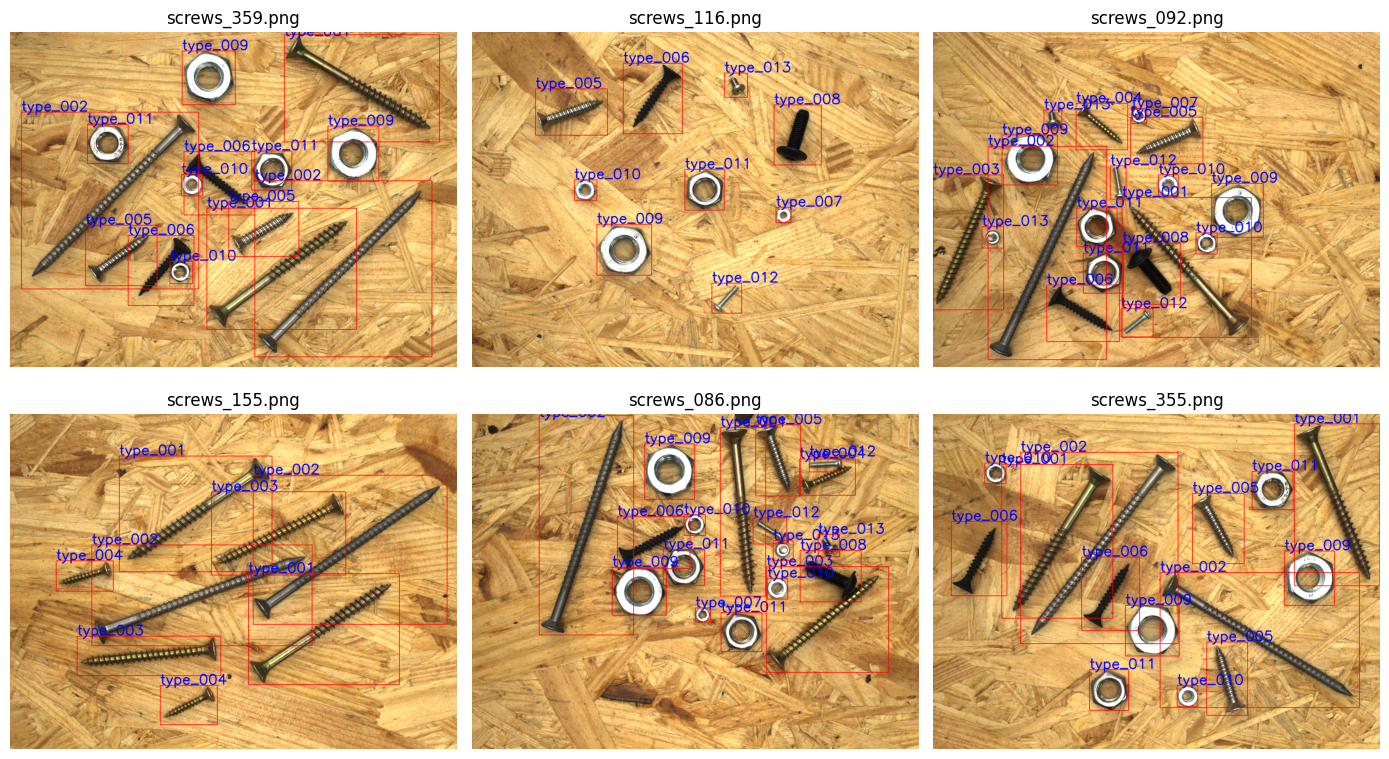

In [8]:
import cv2
import random
import matplotlib.pyplot as plt

def draw_yolo_labels(img_path, lbl_path, names, max_boxes=20):
    img = cv2.imread(str(img_path))
    H, W = img.shape[:2]

    if lbl_path.exists():
        lines = lbl_path.read_text().strip().splitlines()
    else:
        lines = []

    for ln in lines[:max_boxes]:
        parts = ln.split()
        cls = int(parts[0])
        cx, cy, w, h = map(float, parts[1:])

        x1 = int((cx - w/2) * W)
        y1 = int((cy - h/2) * H)
        x2 = int((cx + w/2) * W)
        y2 = int((cy + h/2) * H)

        cv2.rectangle(img, (x1,y1), (x2,y2), (0,0,255), 2)
        cv2.putText(img, names[cls], (x1, max(15,y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 2, (255,0,0), 4, cv2.LINE_AA)        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img_rgb

samples = random.sample(list((IMG_OUT/"train").glob("*.png")) + list((IMG_OUT/"train").glob("*.jpg")), k=6)
plt.figure(figsize=(14,8))
for i, p in enumerate(samples, 1):
    lbl = (LBL_OUT/"train"/(p.stem + ".txt"))
    vis = draw_yolo_labels(p, lbl, names_train)
    plt.subplot(2,3,i)
    plt.imshow(vis)
    plt.axis("off")
    plt.title(p.name)
plt.tight_layout()
plt.show()

### Celda 9: Entrenamiento “smoke test” (para control rápido con 3 epocas)


In [9]:
import torch
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))

Tesla T4
(7, 5)


In [10]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")  # base detect
results = model.train(
    data=str(yaml_path),
    epochs=3,
    imgsz=640,
    batch=8,
    device=0,
    project="/kaggle/working/runs",
    name="mvtec_smoketest"
)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/mvtec_yolo/mvtec_screws.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mvtec_smoketest, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

### Celda 10: Entrenamiento final (con 30 epocas)


In [11]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
results = model.train(
    data=str(yaml_path),
    epochs=30,
    imgsz=640,
    batch=8,
    device=0,
    project="/kaggle/working/runs",
    name="mvtec_final"
)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/mvtec_yolo/mvtec_screws.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mvtec_final, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

### Celda 11: Export a ONNX

In [12]:
from ultralytics import YOLO
from pathlib import Path

run_dir = Path("/kaggle/working/runs/mvtec_final")
best_pt = run_dir / "weights" / "best.pt"

assert best_pt.exists(), f"No existe: {best_pt}. #Revisar si el run se llamo mvtec_final2 o si se reinicio el runtime."

model = YOLO(str(best_pt))
onnx_path = model.export(format="onnx", opset=12, simplify=True)
print("ONNX exportado en:", onnx_path)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 101 layers, 2,584,687 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/kaggle/working/runs/mvtec_final/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 17, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 336ms
 Downloaded onnxruntime
Prepared 2 packages in 344ms
Installed 2 packages in 17ms
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with onnxslim 0.1.94...
ONNX: 

### Celda 12: Empaquetar para descargar (pt + onnx + yaml + class_names)

In [13]:
import shutil
from pathlib import Path

EXPORT_DIR = Path("/kaggle/working/export_mvtec")
EXPORT_DIR.mkdir(exist_ok=True)

# Copiar ONNX y best.pt
shutil.copy(best_pt, EXPORT_DIR / "best.pt")
shutil.copy(onnx_path, EXPORT_DIR / "best.onnx")

# Copiar yaml y nombres
shutil.copy(yaml_path, EXPORT_DIR / "mvtec_screws.yaml")
shutil.copy(OUT_ROOT / "meta" / "class_names.txt", EXPORT_DIR / "class_names.txt")

# ZIP
zip_path = shutil.make_archive("/kaggle/working/mvtec_yolo_export", "zip", EXPORT_DIR)
print("ZIP listo:", zip_path)


ZIP listo: /kaggle/working/mvtec_yolo_export.zip
